In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import geopandas as gpd
from shapely.geometry import Point
import zipfile
from lxml import etree
import requests
from io import BytesIO
import ast
from collections import Counter
import re
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "colab"
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn import tree
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, recall_score
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.utils import resample
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


# Spatial Feature Engineering: Distances to Transit & Attractions

In [ ]:
def extract_bart_stations_from_kmz(kmz_path):
    """
    Extract BART station coordinates from a KMZ file.
    Returns a GeoDataFrame with station locations.
    """

    # If it's a URL, download to memory first
    if isinstance(kmz_path, str) and kmz_path.startswith("http"):
        resp = requests.get(kmz_path)
        resp.raise_for_status()
        kmz_file = BytesIO(resp.content)
    else:
        # assume it's a local file path
        kmz_file = kmz_path

    with zipfile.ZipFile(kmz_file, 'r') as kmz:
        # Usually the KML file is named doc.kml, but let's find it
        kml_files = [name for name in kmz.namelist() if name.endswith('.kml')]
        if not kml_files:
            raise ValueError("No KML file found in KMZ archive")

        kml_file = kml_files[0]
        # Read the data while the file is still open
        kml_data = kmz.read(kml_file)

    # Now parse KML after closing the zip file
    root = etree.fromstring(kml_data)

    # Define KML namespace
    ns = {'kml': 'http://www.opengis.net/kml/2.2'}

    stations = []

    # Extract placemarks (stations)
    for placemark in root.xpath('//kml:Placemark', namespaces=ns):
        name_elem = placemark.find('kml:name', namespaces=ns)
        name = name_elem.text if name_elem is not None else 'Unknown'

        # Get coordinates
        coord_elem = placemark.find('.//kml:coordinates', namespaces=ns)
        if coord_elem is not None:
            coords = coord_elem.text.strip().split(',')
            lon, lat = float(coords[0]), float(coords[1])
            stations.append({'name': name, 'lat': lat, 'lon': lon})

    # Create GeoDataFrame
    bart_gdf = gpd.GeoDataFrame(
        stations,
        geometry=[Point(s['lon'], s['lat']) for s in stations],
        crs='EPSG:4326'  # WGS84
    )

    return bart_gdf

# Step 2: Calculate distances from each location to nearest BART station
def calculate_distances_to_nearest_bart(df, bart_gdf, lat_col='latitude', lon_col='longitude'):
    """
    Calculate distance from each location in df to nearest BART station.

    Parameters:
    - df: DataFrame with latitude and longitude columns
    - bart_gdf: GeoDataFrame of BART stations
    - lat_col: name of latitude column in df
    - lon_col: name of longitude column in df

    Returns:
    - DataFrame with added columns: nearest_bart_station, distance_to_bart_km
    """
    # Create GeoDataFrame from your locations
    locations_gdf = gpd.GeoDataFrame(
        df,
        geometry=[Point(lon, lat) for lon, lat in zip(df[lon_col], df[lat_col])],
        crs='EPSG:4326'
    )

    # Convert to a projected CRS for accurate distance calculation (meters)
    # Using UTM Zone 10N which covers the Bay Area
    locations_gdf_proj = locations_gdf.to_crs('EPSG:32610')
    bart_gdf_proj = bart_gdf.to_crs('EPSG:32610')

    # Calculate distance to each BART station
    distances = []
    nearest_stations = []

    for idx, location in locations_gdf_proj.iterrows():
        # Calculate distance to all BART stations
        dists = bart_gdf_proj.geometry.distance(location.geometry)

        # Find nearest station
        min_dist_idx = dists.idxmin()
        min_dist = dists.min()

        distances.append(min_dist / 1000)  # Convert meters to kilometers
        nearest_stations.append(bart_gdf.loc[min_dist_idx, 'name'])

    # Add results to original DataFrame
    result_df = df.copy()
    result_df['nearest_bart_station'] = nearest_stations
    result_df['distance_to_bart_km'] = distances
    result_df['distance_to_bart_miles'] = result_df['distance_to_bart_km'] * 0.621371

    return result_df

In [ ]:
def calculate_distances_to_nearest(df, places_df, name,
                                        lat_col='latitude', lon_col='longitude',
                                        place_lat_col='latitude', place_lon_col='longitude',
                                        name_of_place = "muni"):
    """
    Calculate distance from each location in df to nearest Muni station.

    Parameters:
    - df: DataFrame with latitude and longitude columns (your original data)
    - places_df: DataFrame of places with name (of place), lat, lon columns
    - lat_col: name of latitude column in df
    - lon_col: name of longitude column in df
    - place_lat_col: name of latitude column in muni_df
    - place_lon_col: name of longitude column in muni_df

    Returns:
    - DataFrame with added columns: nearest_muni_station, distance_to_muni_km, distance_to_muni_miles
    """
    # Create GeoDataFrame from your locations
    locations_gdf = gpd.GeoDataFrame(
        df,
        geometry=[Point(lon, lat) for lon, lat in zip(df[lon_col], df[lat_col])],
        crs='EPSG:4326'
    )

    # Create GeoDataFrame from Muni stations
    place_gdf = gpd.GeoDataFrame(
        places_df,
        geometry=[Point(lon, lat) for lon, lat in zip(places_df[place_lon_col], places_df[place_lat_col])],
        crs='EPSG:4326'
    )

    # Convert to a projected CRS for accurate distance calculation (meters)
    # Using UTM Zone 10N which covers the Bay Area
    locations_gdf_proj = locations_gdf.to_crs('EPSG:32610')
    place_gdf_proj = place_gdf.to_crs('EPSG:32610')

    # Calculate distance to each Muni station
    distances = []
    nearest_stations = []

    for idx, location in locations_gdf_proj.iterrows():
        # Calculate distance to all Muni stations
        dists = place_gdf_proj.geometry.distance(location.geometry)

        # Find nearest station
        min_dist_idx = dists.idxmin()
        min_dist = dists.min()

        distances.append(min_dist / 1000)  # Convert meters to kilometers
        nearest_stations.append(places_df.loc[min_dist_idx, name])

    # Add results to original DataFrame
    result_df = df.copy()
    result_df[f'nearest_{name_of_place}'] = nearest_stations
    result_df[f'distance_to_{name_of_place}_km'] = distances
    result_df[f'distance_to_{name_of_place}_miles'] = result_df[f'distance_to_{name_of_place}_km'] * 0.621371

    return result_df

In [ ]:
def calculate_distances_to(df, name, target_lat, target_lon,
                            lat_col='latitude', lon_col='longitude'):
    """
    Calculate distance from each location in df to specified location.

    Parameters:
    - df: DataFrame with latitude and longitude columns (your original data)
    - name: name of location
    - target_lat: latitude of target location
    - target_long: longtidude of target location
    - lat_col: name of latitude column in df
    - lon_col: name of longitude column in df


    Returns:
    - DataFrame with added columns: distance_to_{name}
    """
    # Create GeoDataFrame from your locations
    locations_gdf = gpd.GeoDataFrame(
        df,
        geometry=[Point(lon, lat) for lon, lat in zip(df[lon_col], df[lat_col])],
        crs='EPSG:4326'
    )

    # Create gdf to target point
    target_point = gpd.GeoDataFrame(
        {'name': ['target']},
        geometry=[Point(target_lon, target_lat)],
        crs='EPSG:4326'
    )

    # Convert to a projected CRS for accurate distance calculation (meters)
    # Using UTM Zone 10N which covers the Bay Area
    locations_gdf_proj = locations_gdf.to_crs('EPSG:32610')
    target_point_proj = target_point.to_crs('EPSG:32610')

   # Calculate distance from each location to the target point
    distances_m = locations_gdf_proj.geometry.distance(target_point_proj.geometry.iloc[0])

    # Add results to original DataFrame
    result_df = df.copy()
    result_df[f'distance_to_{name}_km'] = distances_m / 1000  # Convert meters to kilometers
    result_df[f'distance_to_{name}_miles'] = result_df[f'distance_to_{name}_km'] * 0.621371


    return result_df

# Merge datasets

In [ ]:
dec = pd.read_csv("https://raw.githubusercontent.com/jamparque/airbnb-data/main/listings_dec24.csv")
jun = pd.read_csv("https://raw.githubusercontent.com/jamparque/airbnb-data/main/listings_jun25.csv")
mar = pd.read_csv("https://raw.githubusercontent.com/jamparque/airbnb-data/main/listings_mar25.csv")
sep = pd.read_csv("https://raw.githubusercontent.com/jamparque/airbnb-data/main/listings_sep25.csv")

merged = pd.concat([dec,jun,mar,sep])
merged.shape

(31278, 79)

In [ ]:
kmz_url = "https://github.com/jamparque/airbnb-data/raw/main/BART_Stations_2025.kmz"
bart = extract_bart_stations_from_kmz(kmz_url)
merged_bart = calculate_distances_to_nearest_bart(merged, bart, 'latitude', 'longitude')

In [ ]:
muni = pd.read_csv("https://raw.githubusercontent.com/jamparque/airbnb-data/main/Muni_Stops_20251114.csv")
merged_muni = calculate_distances_to_nearest(merged_bart, muni, 'STOPNAME', 'latitude', 'longitude', 'LATITUDE', 'LONGITUDE')

In [ ]:
attractions = pd.read_csv('https://raw.githubusercontent.com/jamparque/airbnb-data/main/sf_attractions.csv', encoding_errors = 'ignore')
airbnb_bart_muni_attraction = calculate_distances_to_nearest(merged_muni, attractions, 'attraction','latitude', 'longitude', 'latitude', 'longitude', 'attraction')
airbnb_bart_muni_attraction.shape

(31278, 88)

## Show the closest BART / Muni / attraction for a few listings

In [ ]:
cols = [
    "id", "neighbourhood_cleansed", "price",
    "nearest_bart_station", "distance_to_bart_miles",
    "nearest_muni", "distance_to_muni_miles",
    "nearest_attraction", "distance_to_attraction_miles"
]

airbnb_bart_muni_attraction[cols].head(3)

,id,neighbourhood_cleansed,price,nearest_bart_station,distance_to_bart_miles,nearest_muni,distance_to_muni_miles,nearest_attraction,distance_to_attraction_miles
0,45625654,Nob Hill,$140.00,Powell St,0.759681,Washington St&Taylor St S-MI,0.042340,Nob Hill,0.172722
1,1286092437845953764,Western Addition,$360.00,16th St/Mission,0.999065,Hayes St&Steiner St NW-FS/BZ,0.040345,The Painted Ladies,0.130565
2,9844630,Noe Valley,NaN,24th St/Mission,0.973625,Castro St&23RD St W-MI/SB,0.106217,Seward Mini Park,0.390443


## Distributions of distances

       distance_to_bart_miles  distance_to_muni_miles  \
count            31278.000000            31278.000000   
mean                 1.140990                0.062382   
std                  0.991546                0.041680   
min                  0.002151                0.000503   
25%                  0.424805                0.032296   
50%                  0.779546                0.052168   
75%                  1.530895                0.082810   
max                  5.101788                0.444493   

       distance_to_attraction_miles  
count                  31278.000000  
mean                       0.631713  
std                        0.684430  
min                        0.004588  
25%                        0.206671  
50%                        0.381730  
75%                        0.735645  
max                        3.734098  


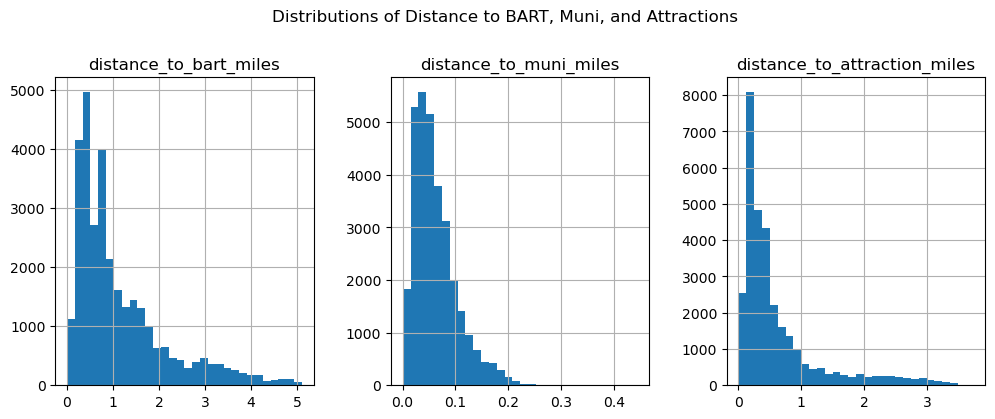

In [ ]:
dist_cols = [
    "distance_to_bart_miles",
    "distance_to_muni_miles",
    "distance_to_attraction_miles"
]

print(airbnb_bart_muni_attraction[dist_cols].describe())

airbnb_bart_muni_attraction[dist_cols].hist(
    bins=30, figsize=(12, 4), layout=(1, 3)
)
plt.suptitle("Distributions of Distance to BART, Muni, and Attractions", y=1.05)
plt.show()

## Relationship with price

In [ ]:
# Remove $ and commas, then convert to float
airbnb_bart_muni_attraction["price"] = (
    airbnb_bart_muni_attraction["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [ ]:
airbnb_bart_muni_attraction[
    ["price", "distance_to_bart_miles", "distance_to_muni_miles", "distance_to_attraction_miles"]
].corr()

,price,distance_to_bart_miles,distance_to_muni_miles,distance_to_attraction_miles
price,1.000000,-0.035800,-0.031409,-0.047710
distance_to_bart_miles,-0.035800,1.000000,0.173174,0.136253
distance_to_muni_miles,-0.031409,0.173174,1.000000,0.238668
distance_to_attraction_miles,-0.047710,0.136253,0.238668,1.000000


# Map

In [ ]:
# Prepare BART station dataframe
bart_df = bart.copy()
bart_df["lat"] = bart_df.geometry.y
bart_df["lon"] = bart_df.geometry.x

# Prepare Muni DataFrame
muni_df = muni.copy()
muni_df["lat"] = muni_df["LATITUDE"]
muni_df["lon"] = muni_df["LONGITUDE"]

# Prepare Attractions DataFrame
attractions_df = attractions.copy()
attractions_df["lat"] = attractions_df["latitude"]
attractions_df["lon"] = attractions_df["longitude"]

# Unique Airbnb listings
df_props = airbnb_bart_muni_attraction.drop_duplicates(subset="id")


## Airbnb Properties + BART Stations Map

In [ ]:
fig_bart = go.Figure()

# -----------------------------
# 1. Airbnb properties — small, semi-transparent red points
# -----------------------------
fig_bart.add_trace(go.Scattermapbox(
    lat=df_props["latitude"],
    lon=df_props["longitude"],
    mode="markers",
    name="Airbnb Properties",
    marker=dict(
        size=4,                                  # smaller points to reduce clutter
        color="rgba(220, 20, 60, 0.35)",         # semi-transparent red
    ),
    hoverinfo="skip"                             # turn off hover for every single Airbnb point
))

# -----------------------------
# 2. BART stations — main focus: bigger blue dots with labels
# -----------------------------
fig_bart.add_trace(go.Scattermapbox(
    lat=bart_df["lat"],
    lon=bart_df["lon"],
    mode="markers+text",
    name="BART Stations",
    marker=dict(
        size=14,
        color="royalblue",                       # keep it solid blue
        # no 'line' here because this Plotly version doesn't support marker.line
    ),
    text=bart_df["name"],                        # station names
    textposition="top center",
    hoverinfo="text",
    hovertext=bart_df["name"]
))

# -----------------------------
# 3. Layout — closer zoom, centered on SF, nice legend
# -----------------------------
fig_bart.update_layout(
    mapbox=dict(
        style="carto-positron",
        zoom=12,                                 # slightly closer than 11.5
        center=dict(lat=37.77, lon=-122.42)
    ),
    title="Airbnb Properties and BART Stations in San Francisco",
    margin=dict(r=0, l=0, t=40, b=0),
    legend=dict(
        title="Layers",
        bgcolor="rgba(255,255,255,0.85)",
        bordercolor="rgba(0,0,0,0.1)",
        borderwidth=1,
        yanchor="top", y=0.99,
        xanchor="right", x=0.99,
        font=dict(size=13)
    ),
    height=650
)

fig_bart.show()


## Airbnb Properties + Muni Stops Map

In [ ]:
fig_muni = go.Figure()

# Airbnb properties (light red, background points)
fig_muni.add_trace(go.Scattermapbox(
    lat=df_props["latitude"],
    lon=df_props["longitude"],
    mode="markers",
    marker=dict(
        size=4,
        color="rgba(255, 80, 120, 0.25)"   # lighter, transparent red
    ),
    name="Airbnb Properties",
))

# Muni stops (BRIGHT GREEN, larger circles)
fig_muni.add_trace(go.Scattermapbox(
    lat=muni_df["lat"],
    lon=muni_df["lon"],
    mode="markers",
    marker=dict(
        size=10,                # bigger so they stand out
        color="limegreen",      # bright green
        # symbol="circle"       # optional, default is circle
    ),
    name="Muni Stops",
    hovertext=muni_df["STOPNAME"],
    hoverinfo="text"
))

fig_muni.update_layout(
    mapbox=dict(
        style="carto-positron",           # nicer gray base map
        zoom=11.5,
        center=dict(lat=37.77, lon=-122.44)
    ),
    title="Airbnb Properties (Light Red) and Muni Stops (Green)",
    margin={"r":0,"l":0,"t":40,"b":0},
    height=700
)

fig_muni.show()



##  Airbnb Properties + Attractions Map

In [ ]:
fig_attract = go.Figure()

# Airbnb properties (light pink background)
fig_attract.add_trace(go.Scattermapbox(
    lat=df_props["latitude"],
    lon=df_props["longitude"],
    mode="markers",
    marker=dict(
        size=3,
        color="rgba(255, 80, 120, 0.25)"   # light, transparent pink
    ),
    name="Airbnb Properties",
    hoverinfo="skip"                       # do not show hover for every listing
))

# Attractions with names shown on map
fig_attract.add_trace(go.Scattermapbox(
    lat=attractions_df["lat"],
    lon=attractions_df["lon"],

    # text labels
    mode="markers+text",
    text=attractions_df["attraction"],     # attractions
    textposition="top center",
    textfont=dict(size=11, color="purple"),

    marker=dict(
        size=14,                           # large so they stand out
        color="purple"                     # solid purple
    ),
    name="Attractions",
    hovertext=attractions_df["attraction"],
    hoverinfo="text"
))

fig_attract.update_layout(
    mapbox=dict(
        style="carto-positron",            # clean gray base map
        zoom=11.5,
        center=dict(lat=37.77, lon=-122.44)
    ),
    title="Airbnb Properties (Light Pink) and Attractions (Purple)",
    margin={"r":0, "l":0, "t":40, "b":0},
    height=700
)

fig_attract.show()

### Extract Year and Month

In [ ]:
# Convert last_scraped to datetime
airbnb_bart_muni_attraction["last_scraped"] = pd.to_datetime(
    airbnb_bart_muni_attraction["last_scraped"], errors="coerce"
)

# Extract YYYY-MM
airbnb_bart_muni_attraction["year_month"] = (
    airbnb_bart_muni_attraction["last_scraped"].dt.to_period("M").astype(str)
)

# Drop the original last_scraped column
airbnb_bart_muni_attraction = airbnb_bart_muni_attraction.drop(columns=["last_scraped"])

# Preview
airbnb_bart_muni_attraction.shape

(31278, 88)

# Data Cleaning

In [ ]:
def clean_data(df):
    # Replace 'id' with the string after the last "/" in 'listing_url', converted to float and back to string without scientific notation
    mask = df['id'].astype(str).str.contains('e+', na=False)
    df.loc[mask, 'id'] = df.loc[mask, 'listing_url'].str.split('/').str[-1].astype(float).map('{:.0f}'.format)
    # Convert 'id' column to int data type
    df['id'] = df['id'].astype(str)
    return df

attraction = clean_data(airbnb_bart_muni_attraction.copy())

In [ ]:
# Drop columns
attraction  = attraction.drop(columns=['neighbourhood', 'neighbourhood_group_cleansed', 'calendar_updated', 'listing_url',
                                       'scrape_id', 'source', 'picture_url', 'host_url', 'host_thumbnail_url', 'host_picture_url',
                                       'host_neighbourhood', 'calendar_last_scraped'])

### Investigate Room Type

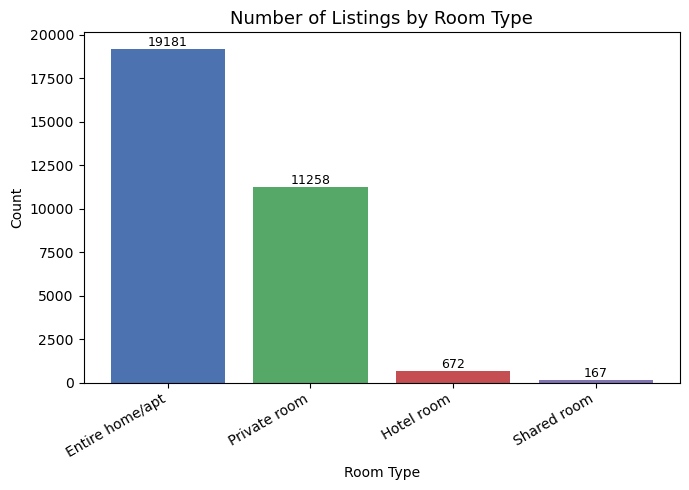

In [ ]:
import matplotlib.pyplot as plt

# Prepare data
counts = attraction["room_type"].value_counts()

# Colors for each room type (you can adjust if you want)
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

plt.figure(figsize=(7,5))
bars = plt.bar(
    counts.index,
    counts.values,
    color=colors
)

plt.title("Number of Listings by Room Type", fontsize=13)
plt.xlabel("Room Type")
plt.ylabel("Count")

# Rotate x-axis labels
plt.xticks(rotation=30, ha="right")

# Optional: add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [ ]:
summary_table = (
    attraction.groupby("room_type")["price"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False))

summary_table
# The price patterns for "=Hotel rooms and Shared rooms are extremely noisy and not representative.

,count,mean,median,std,min,max
room_type,,,,,,
Hotel room,312,6994.679487,234.0,15822.746768,72.0,50000.0
Shared room,116,399.155172,51.0,1752.361838,28.0,10000.0
Entire home/apt,15481,324.979975,199.0,1362.138283,9.0,50000.0
Private room,7891,136.159929,87.0,342.415564,22.0,10000.0


In [ ]:
# Drop rows in room_type and property_type
attraction = attraction[(attraction['room_type'] != 'Hotel room') & (attraction['room_type'] != 'Shared room')]

In [ ]:
df_prices = attraction.groupby(["latitude", "longitude", "room_type"])["price"].mean().reset_index()
df_prices.head()

,latitude,longitude,room_type,price
0,37.708280,-122.461640,Entire home/apt,146.0
1,37.708394,-122.428893,Entire home/apt,113.0
2,37.708440,-122.463400,Entire home/apt,125.0
3,37.708460,-122.420720,Private room,50.0
4,37.708480,-122.469480,Private room,71.0


In [ ]:
df_home_price = df_prices[df_prices['room_type']=="Entire home/apt"]
df_room_price = df_prices[df_prices['room_type']=="Private room"]

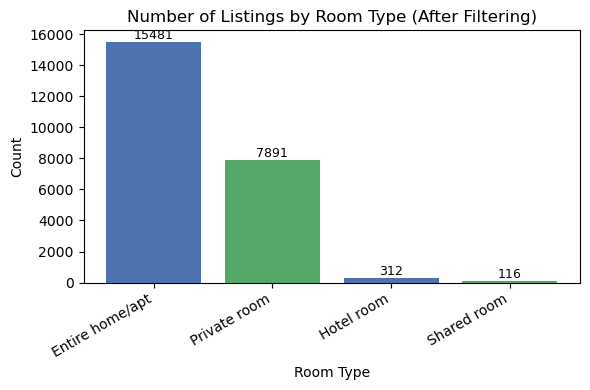

In [ ]:
import matplotlib.pyplot as plt

# Use the count column from your summary table
counts = summary_table["count"].sort_values(ascending=False)

# pick colors (2 categories now)
colors = ["#4C72B0", "#55A868"]

plt.figure(figsize=(6,4))
bars = plt.bar(counts.index, counts.values, color=colors)

plt.title("Number of Listings by Room Type (After Filtering)", fontsize=12)
plt.xlabel("Room Type")
plt.ylabel("Count")

# rotate x labels
plt.xticks(rotation=30, ha="right")

# add value labels
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, f"{int(h)}",
             ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
summary_table = (
    attraction.groupby("room_type")["price"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

summary_table

,count,mean,median,std,min,max
room_type,,,,,,
Entire home/apt,15481,324.979975,199.0,1362.138283,9.0,50000.0
Private room,7891,136.159929,87.0,342.415564,22.0,10000.0


**We can clearly see the presence of price outliers from the large gaps between the median and maximum prices. We will investigate and resolve this in later sections.**

### Investigate Property Type

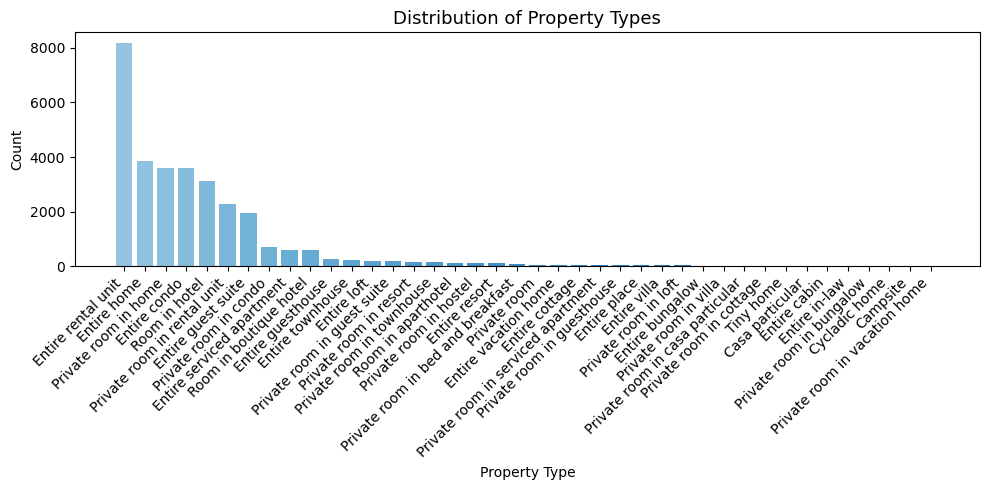

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get counts
counts = attraction["property_type"].value_counts()

colors = plt.cm.Blues(
    np.linspace(0.4, 0.9, len(counts))
)

plt.figure(figsize=(10,5))
bars = plt.bar(
    counts.index,
    counts.values,
    color=colors
)

plt.title("Distribution of Property Types", fontsize=13)
plt.xlabel("Property Type")
plt.ylabel("Count")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


In [ ]:
# Group Property Type
attraction['property_type'].value_counts(normalize=True, ascending = True).head(7)

property_type
Private room in vacation home    0.000066
Campsite                         0.000099
Cycladic home                    0.000099
Entire in-law                    0.000131
Entire cabin                     0.000131
Private room in bungalow         0.000131
Casa particular                  0.000164
Name: proportion, dtype: float64

In [ ]:
top_property_types = attraction['property_type'].value_counts().head(7).index.tolist()

attraction['property_type_grouped'] = attraction['property_type'].apply(
    lambda x: x if x in top_property_types else 'Other'
)

print(attraction['property_type_grouped'].value_counts(normalize=True))

attraction = pd.get_dummies(attraction, columns=['property_type_grouped'], drop_first=True, dtype=int)

property_type_grouped
Entire rental unit             0.268209
Other                          0.128125
Entire home                    0.126910
Private room in home           0.117678
Entire condo                   0.117678
Room in hotel                  0.102894
Private room in rental unit    0.074871
Entire guest suite             0.063635
Name: proportion, dtype: float64


In [ ]:
def remove_properties(df, column):
    properties_to_remove = ['Room in hotel', 'Room in boutique hotel',
                            'Private room in hostel', 'Room in aparthotel',
                            'Private room in bed and breakfast',
                            'Entire resort', 'Campsite']
    df = df[~df[column].isin(properties_to_remove)]
    return df

attraction = remove_properties(attraction, 'property_type')

In [ ]:
# Group Property Type after removing properties_to_remove
attraction['property_type'].value_counts(normalize=True, ascending = True).head(7)

property_type
Private room in vacation home    0.000076
Cycladic home                    0.000114
Private room in bungalow         0.000152
Entire in-law                    0.000152
Entire cabin                     0.000152
Casa particular                  0.000190
Tiny home                        0.000266
Name: proportion, dtype: float64

## Hot Encode

In [ ]:
# Binary Columns
attraction['has_description'] = attraction['description'].notna().astype(int)
attraction['has_neighborhood_overview'] = attraction['neighborhood_overview'].notna().astype(int)
attraction['has_host_about'] = attraction['host_about'].notna().astype(int)
attraction['host_with_profile_pic'] = (attraction['host_has_profile_pic'] == 't').astype(int)
attraction['host_has_identity_verified'] = (attraction['host_identity_verified'] == 't').astype(int)
attraction['has_instant_bookable'] = (attraction['instant_bookable'] == 't').astype(int)
attraction['is_sf'] = attraction['host_location'].str.contains('San Francisco', case=False, na=False).astype(int) # or another value

In [ ]:
attraction["host_is_superhost"] = (attraction["host_is_superhost"].astype(str).replace({"t": 1, "f": 0}).where(lambda x: x.isin([1, 0]),0).astype(int))
attraction
attraction.shape

(26277, 90)

In [ ]:
# host_since column
attraction['host_since_year'] = pd.to_datetime(attraction['host_since'], errors='coerce').dt.year
attraction['host_since_year'] = attraction['host_since_year'].fillna(0).astype(int)
attraction['host_since_year'] = attraction['host_since_year'].astype(int)

In [ ]:
# room_type
attraction['is_entire_home'] = (attraction['room_type'] == 'Entire home/apt').astype(int)

In [ ]:
# host_response_time
response_time_order = {
    'within an hour': 4,
    'within a few hours': 3,
    'within a day': 2,
    'a few days or more': 1,
    np.nan: 0
}
attraction['host_response_time_ordinal'] = attraction['host_response_time'].map(response_time_order)

In [ ]:
# host_verification
attraction['host_verifications_missing'] = attraction['host_verifications'].isna().astype(int)
attraction['has_email_verified'] = attraction['host_verifications'].str.contains('email', na=False).astype(int)
attraction['has_phone_verified'] = attraction['host_verifications'].str.contains('phone', na=False).astype(int)
attraction['has_work_email_verified'] = attraction['host_verifications'].str.contains('work_email', na=False).astype(int)

In [ ]:
# Percentage to Float
percentage_columns = ['host_response_rate', 'host_acceptance_rate']

for col in percentage_columns:
    attraction[col] = attraction[col].str.rstrip('%').astype(float)/100


### Amenities

In [ ]:
LUXURY_KEYWORDS = ['pool', 'hot tub', 'gym', 'ev charger', 'sauna', 'indoor fireplace',
                'private hot tub', 'shared hot tub', 'exercise equipment', 'piano',
                'movie theater', 'resort access', 'waterfront', 'ocean view', 'bay view',
                'beach view', 'mountain view', 'city skyline view', 'pool table',
                'game console', 'sound system', 'smart lock', 'bidet', 'private gym','shared gym', 'building staff']

SAFETY_KEYWORDS = ['smoke alarm', 'carbon monoxide alarm', 'fire extinguisher', 'first aid kit',
                'lock on bedroom door', 'safe', 'security cameras', 'keypad', 'lockbox',
                'smart lock', 'fireplace guards', 'window guards', 'outlet covers',
                'baby safety gates', 'table corner guards']

CONVENIENCE_KEYWORDS = ['wifi', 'washer', 'dryer', 'parking', 'elevator', 'air conditioning', 'heating',
                'kitchen', 'dishwasher', 'microwave', 'refrigerator', 'oven', 'stove',
                'coffee maker', 'self check-in', 'tv', 'dedicated workspace', 'iron',
                'hair dryer', 'hangers', 'essentials', 'hot water', 'shampoo', 'conditioner',
                'body soap', 'shower gel', 'free street parking', 'free parking',
                'paid parking', 'private entrance', 'luggage dropoff', 'long term stays',
                'laundromat nearby', 'cleaning available', 'breakfast', 'mini fridge']

OUTDOOR_KEYWORDS = ['backyard', 'patio', 'balcony', 'bbq grill', 'beach access', 'garden',
                'outdoor furniture', 'outdoor dining', 'fire pit', 'sun loungers',
                'outdoor playground', 'hammock', 'bikes', 'shared backyard',
                'private backyard', 'outdoor kitchen', 'barbecue utensils']


In [ ]:
def count_amenity_category(amenity_list_str, keywords):
    if pd.isna(amenity_list_str):
        return 0
    try:
        amenities = ast.literal_eval(amenity_list_str)
        amenities_lower = [str(amenity).lower() for amenity in amenities]

        count = 0
        found_keywords = set()

        for amenity in amenities_lower:
            for keyword in keywords:
                if keyword in amenity and keyword not in found_keywords:
                    count += 1
                    found_keywords.add(keyword)

        return count
    except Exception:
        return 0

In [ ]:
def count_total_amenities(amenity_list_str):
    if pd.isna(amenity_list_str):
        return 0
    try:
        amenities = ast.literal_eval(amenity_list_str)
        return len(amenities)
    except Exception:
        return 0

In [ ]:
def create_all_amenity_features(df, amenity_column='amenities'):
 # Count features for each category
    df['luxury_amenity_count'] = df[amenity_column].apply(lambda x: count_amenity_category(x, LUXURY_KEYWORDS))
    df['safety_amenity_count'] = df[amenity_column].apply(lambda x: count_amenity_category(x, SAFETY_KEYWORDS))
    df['convenience_amenity_count'] = df[amenity_column].apply(lambda x: count_amenity_category(x, CONVENIENCE_KEYWORDS))
    df['outdoor_amenity_count'] = df[amenity_column].apply(lambda x: count_amenity_category(x, OUTDOOR_KEYWORDS))
    # Binary features (has ANY amenity in category)
    df['has_luxury_amenity'] = (df['luxury_amenity_count'] > 0).astype(int)
    df['has_safety_amenity'] = (df['safety_amenity_count'] > 0).astype(int)
    df['has_convenience_amenity'] = (df['convenience_amenity_count'] > 0).astype(int)
    df['has_outdoor_amenity'] = (df['outdoor_amenity_count'] > 0).astype(int)
    # Total and derived features
    df['total_amenity_count'] = df[amenity_column].apply(count_total_amenities)
    df['premium_amenity_ratio'] = df.apply(
        lambda row: row['luxury_amenity_count'] / row['total_amenity_count']
        if row['total_amenity_count'] > 0 else 0, axis=1)
    # Did ordinal ranking again
    df['amenity_score'] = (
        df['luxury_amenity_count'] * 3 +
        df['outdoor_amenity_count'] * 2 +
        df['safety_amenity_count'] * 1 +
        df['convenience_amenity_count'] * 1)
    return df

In [ ]:
df = create_all_amenity_features(attraction, amenity_column='amenities')

amenity_cols = [col for col in df.columns if 'amenity' in col.lower()]
print(f"Found {len(amenity_cols)} amenity columns:")
print(amenity_cols)

if 'price' in df.columns:
    analysis_cols = amenity_cols + ['price']
else:
    analysis_cols = amenity_cols
    print("\nWarning: 'price' column not found. Analyzing amenities only.")

Found 11 amenity columns:
['luxury_amenity_count', 'safety_amenity_count', 'convenience_amenity_count', 'outdoor_amenity_count', 'has_luxury_amenity', 'has_safety_amenity', 'has_convenience_amenity', 'has_outdoor_amenity', 'total_amenity_count', 'premium_amenity_ratio', 'amenity_score']



CORRELATIONS WITH PRICE
has_luxury_amenity           0.063882
luxury_amenity_count         0.060696
premium_amenity_ratio        0.054942
amenity_score                0.040750
convenience_amenity_count    0.025747
total_amenity_count          0.024853
outdoor_amenity_count        0.015829
has_safety_amenity          -0.003364
has_outdoor_amenity         -0.003918
safety_amenity_count        -0.010678
has_convenience_amenity     -0.014411
dtype: float64


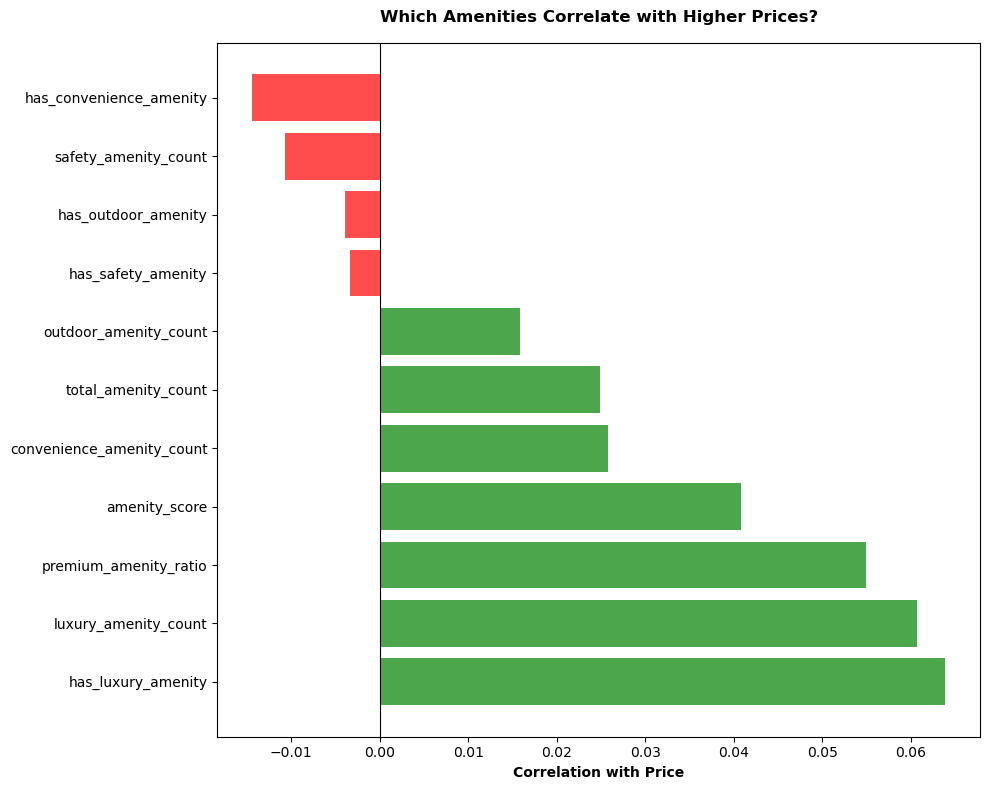

In [ ]:
if 'price' in df.columns:

    price_corr = df[amenity_cols].corrwith(df['price']).sort_values(ascending=False)
    print("\n" + "="*50)
    print("CORRELATIONS WITH PRICE")
    print("="*50)
    print(price_corr)
    plt.figure(figsize=(10, 8))
    colors = ['green' if x > 0 else 'red' for x in price_corr.values]
    plt.barh(range(len(price_corr)), price_corr.values, color=colors, alpha=0.7)
    plt.yticks(range(len(price_corr)), price_corr.index)
    plt.xlabel('Correlation with Price', fontweight='bold')
    plt.title('Which Amenities Correlate with Higher Prices?', fontweight='bold', pad=15)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    plt.tight_layout()
    plt.show()

### Investigate Neighbourhoods

In [ ]:
attraction['neighbourhood_cleansed'].value_counts().head(20)

neighbourhood_cleansed
Downtown/Civic Center    2349
Mission                  2257
South of Market          1921
Western Addition         1757
Outer Sunset             1392
Castro/Upper Market      1164
Nob Hill                 1136
Bernal Heights           1087
Noe Valley                993
Haight Ashbury            940
Inner Richmond            817
Outer Richmond            762
Financial District        726
Marina                    707
Russian Hill              704
North Beach               672
Excelsior                 656
Pacific Heights           645
Inner Sunset              611
Potrero Hill              599
Name: count, dtype: int64

In [ ]:
attraction = attraction.copy()

for neighbourhood in attraction['neighbourhood_cleansed']:
    col_name = f"is_{neighbourhood.lower().replace(' ', '_').replace('-', '_')}"

    attraction[col_name] = attraction['neighbourhood_cleansed'].str.contains(
        neighbourhood, case=False, na=False, regex=False
    ).astype(int)

### Extract Count of Bathrooms from Text

In [ ]:
def extract_bathroom_count(text):
    if pd.isna(text):
        return None
    match = re.search(r'(\d+\.?\d*)', str(text))
    if match:
        return float(match.group(1))
    return None

attraction['bathroom_count'] = attraction['bathrooms_text'].apply(extract_bathroom_count)

attraction['bathroom_count'] = attraction['bathroom_count'].fillna(attraction['bathrooms'])

attraction['is_private_bathroom'] = (~attraction['bathrooms_text'].str.contains('shared', case=False, na=True)).astype(int)

attraction['bathroom_count'] = attraction['bathroom_count'].fillna(attraction['bathroom_count'].fillna(1.0))

## Map by Room Types

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "colab"

#pio.renderers.default = "iframe"

# -------------------------------------------------
# 1. Remove duplicate listings by ID
# -------------------------------------------------
df = attraction.copy()
df_unique = df.drop_duplicates(subset="id", keep="first")

# -------------------------------------------------
# 2. Count listings per location and room type
# -------------------------------------------------
df_counts = (
    df_unique.groupby(["latitude", "longitude", "room_type"])
             .size()
             .reset_index(name="count")
)

# -------------------------------------------------
# 3. Density heatmap layer (light background density)
# -------------------------------------------------
heatmap = px.density_mapbox(
    df_unique,
    lat="latitude",
    lon="longitude",
    radius=5,                       # smaller radius = less exaggerated heatmap
    center=dict(lat=37.76, lon=-122.44),
    zoom=12,
    mapbox_style="carto-positron",
    color_continuous_scale="Blues",
    height=800
)
heatmap.update_traces(opacity=0.25)  # make heatmap very soft/transparent

# -------------------------------------------------
# 4. Bubble layer (by room type, sized by count)
# -------------------------------------------------
bubble = px.scatter_mapbox(
    df_counts,
    lat="latitude",
    lon="longitude",
    color="room_type",   # different traces for each room type
    size="count",        # larger bubbles = more listings
    size_max=22,
    zoom=12
)

# Save the colors used for each room type from the bubble traces
roomtype_colors = {tr.name: tr.marker.color for tr in bubble.data}

# We don't want the original small legend markers from these traces
bubble.update_traces(showlegend=False, marker_opacity=0.8)

# Add bubble traces on top of the heatmap
heatmap.add_traces(bubble.data)

for room_type, color in roomtype_colors.items():
    heatmap.add_trace(
        go.Scattermapbox(
            lat=[37.76],
            lon=[-122.44],
            mode="markers",
            marker=dict(size=16, color=color),
            name=room_type,
            visible="legendonly"
        )
    )

# -------------------------------------------------
# 6. Layout: hide heatmap colorbar, style legend
# -------------------------------------------------
heatmap.update_layout(
    title="Airbnb Listing Density (Balanced Heatmap + Bubbles) in San Francisco",
    margin={"r": 0, "t": 40, "l": 0, "b": 0},
    coloraxis_showscale=False,   # hide blue heatmap colorbar
    legend=dict(
        title="Room Type",
        yanchor="top", y=0.98,
        xanchor="left", x=0.02,
        bgcolor="rgba(255,255,255,0.85)",
        itemsizing="constant",
        font=dict(size=14)
    )
)

heatmap.show()


## Investigate Prices

In [ ]:
df.shape
# Compute percentiles
print("Min:", df["price"].min())
print("25th percentile:", df["price"].quantile(0.25))
print("Median:", df["price"].median())
print("75th percentile:", df["price"].quantile(0.75))
print("Max:", df["price"].max())

# Remove the top 25% most expensive listings
q75 = df["price"].quantile(0.75)
df_clean = df[df["price"] <= q75].copy()

print("Before:", df.shape)
print("After:", df_clean.shape)

Min: 9.0
25th percentile: 100.0
Median: 159.0
75th percentile: 270.0
Max: 50000.0
Before: (26277, 146)
After: (15810, 146)


Text(0, 0.5, 'Count')

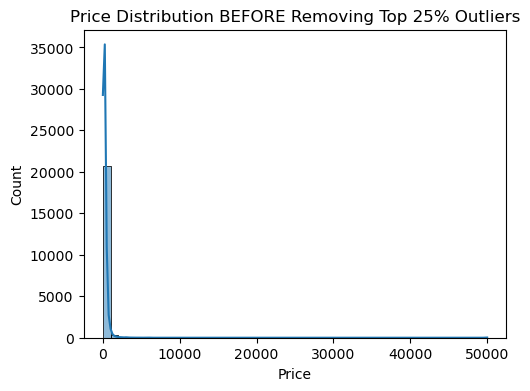

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Price Distribution BEFORE Removing Top 25% Outliers")
plt.xlabel("Price")
plt.ylabel("Count")

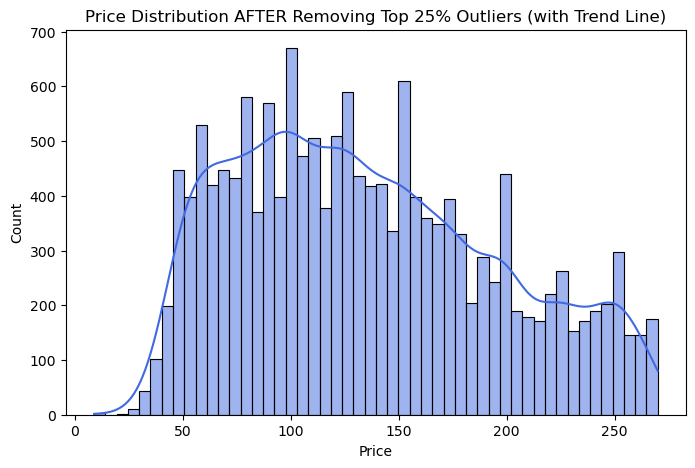

In [ ]:
plt.figure(figsize=(8,5))

# Histogram + KDE trend line
sns.histplot(df_clean["price"], bins=50, kde=True, color="royalblue")

plt.title("Price Distribution AFTER Removing Top 25% Outliers (with Trend Line)")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

In [ ]:
before_stats = {
    "Metric": ["Min", "25th Percentile", "Median", "75th Percentile", "Max", "Total Listings"],
    "Before": [
        df["price"].min(),
        df["price"].quantile(0.25),
        df["price"].median(),
        df["price"].quantile(0.75),
        df["price"].max(),
        df.shape[0]
    ],
    "After": [
        df_clean["price"].min(),
        df_clean["price"].quantile(0.25),
        df_clean["price"].median(),
        df_clean["price"].quantile(0.75),
        df_clean["price"].max(),
        df_clean.shape[0]
    ]
}

comparison_table = pd.DataFrame(before_stats)
comparison_table

,Metric,Before,After
0,Min,9.0,9.0
1,25th Percentile,100.0,87.0
2,Median,159.0,127.0
3,75th Percentile,270.0,178.0
4,Max,50000.0,270.0
5,Total Listings,26277.0,15810.0


In [ ]:
df_clean["price"].isnull().sum()
# The price column contains no missing values, so no imputation is needed.

np.int64(0)

In [ ]:
# Find exact duplicate rows (same id, year_month, price, and all other features)
cols_for_exact = [
    "id",
    "year_month",
    "price"
] + [col for col in df_clean.columns if col not in ["id", "year_month", "price"]]
exact_dups = df_clean[df_clean.duplicated(subset=cols_for_exact, keep=False)].sort_values(["id", "year_month"])

len(exact_dups)

0

In [ ]:
# Group by id + year_month among just the exact duplicates
dup_groups = exact_dups.groupby(["id", "year_month"]).size().sort_values(ascending=False)
len(dup_groups)

0

### Suspicious Bathroom Listings

In [ ]:
# filter suspicious listings
sus = df_clean[
    (df_clean["room_type"].str.contains("Private", case=False, na=False)) &
    (df_clean["bedrooms"] == 1) &
    (df_clean["bathroom_count"] >= 2)
]

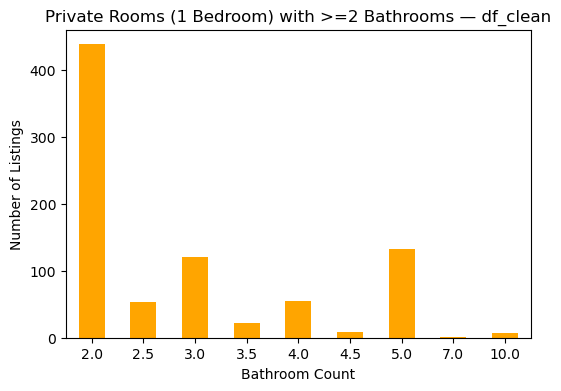

In [ ]:
plt.figure(figsize=(6,4))

sus["bathroom_count"].value_counts().sort_index().plot(
    kind="bar",
    color="orange"
)

plt.title("Private Rooms (1 Bedroom) with >=2 Bathrooms — df_clean")
plt.xlabel("Bathroom Count")
plt.ylabel("Number of Listings")
plt.xticks(rotation=0)
plt.show()

In [ ]:
summary = sus.groupby("bathroom_count")["price"].agg(["count", "mean", "median"]).sort_index()
summary

,count,mean,median
bathroom_count,,,
2.0,438,77.130137,65.0
2.5,53,85.566038,75.0
3.0,121,72.966942,61.0
3.5,22,61.227273,56.5
4.0,55,72.781818,65.0
4.5,8,106.250000,101.5
5.0,132,51.348485,50.0
7.0,1,68.000000,68.0
10.0,7,55.000000,55.0


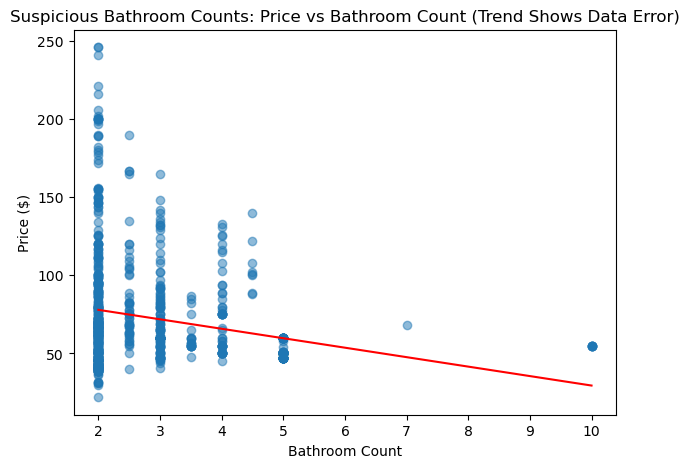

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(sus["bathroom_count"], sus["price"], alpha=0.5)

# Trendline
z = np.polyfit(sus["bathroom_count"], sus["price"], 1)
p = np.poly1d(z)
plt.plot(sorted(sus["bathroom_count"]), p(sorted(sus["bathroom_count"])), color="red")

plt.title("Suspicious Bathroom Counts: Price vs Bathroom Count (Trend Shows Data Error)")
plt.xlabel("Bathroom Count")
plt.ylabel("Price ($)")
plt.show()

In [ ]:
# number rows of suspicious values
len(sus)

837

In [ ]:
# percentage of suspicious values out of dataset
(len(sus) / len(df_clean)) * 100

5.294117647058823

In [ ]:
# keep susipicious values and set their bathroom_count to 1
df_clean.loc[
    (df_clean["room_type"].str.contains("Private", case=False, na=False)) &
    (df_clean["bedrooms"] == 1) &
    (df_clean["bathroom_count"] >= 2),
    "bathroom_count"
] = 1

### Missing Values

In [ ]:
# Check missing values in bathroom_count
df_clean["bathroom_count"].isnull().sum()

np.int64(0)

There is no missing values in bathroom_count

In [ ]:
# Calculate missing-value percentage for each column
missing_percent = df_clean.isnull().mean() * 100

# Sort descending (highest missing first)
missing_sorted = missing_percent.sort_values(ascending=False)

# Show the top 20 columns
missing_sorted.head(20)


license                        45.819102
neighborhood_overview          38.513599
host_about                     34.294750
estimated_revenue_l365d        27.349779
number_of_reviews_ly           27.349779
availability_eoy               27.349779
estimated_occupancy_l365d      27.349779
host_location                  16.786844
review_scores_value            15.167615
review_scores_location         15.167615
review_scores_checkin          15.167615
reviews_per_month              15.142315
review_scores_communication    15.142315
review_scores_cleanliness      15.142315
review_scores_accuracy         15.142315
review_scores_rating           15.142315
last_review                    15.142315
first_review                   15.142315
host_response_rate              7.526882
host_response_time              7.526882
dtype: float64

In [ ]:
#  Select columns with >= 20% missing values
high_percent_cols_to_drop = missing_percent[missing_percent >= 20].index.tolist()

print("Columns dropped (>=20% missing):")
print(high_percent_cols_to_drop)

# 3. Drop them from the dataframe
df_clean = df_clean.drop(columns=high_percent_cols_to_drop)

print("\nNew dataframe shape:", df_clean.shape)


Columns dropped (>=20% missing):
['neighborhood_overview', 'host_about', 'license', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'estimated_revenue_l365d']

New dataframe shape: (15810, 139)


### Drop Unnecessary Features

In [ ]:
non_related = ["first_review", "host_name", "host_listings_count", "host_total_listings_count", "host_since", "host_since_year", "calculated_host_listings_count", "calculated_host_listings_count_entire_homes", "calculated_host_listings_count_private_rooms", "calculated_host_listings_count_shared_rooms", "has_availability", "host_id", "id"]
extra_distance = ["distance_to_attraction_km", "distance_to_bart_km", "distance_to_muni_km"]
extra = ["bathrooms_text", "bathrooms", "host_has_profile_pic", "host_identity_verified", "instant_bookable", "host_response_time", "host_verifications", "property_type"]
df_clean = df_clean.drop(columns=non_related + extra_distance + extra, errors="ignore")

print("\nNew dataframe shape:", df_clean.shape)


New dataframe shape: (15810, 115)


### Numeric Imputation and Log-Price Creation

In [ ]:
df_clean = df_clean.copy()
num_cols_all = df_clean.select_dtypes(include=[np.number]).columns

# Replace inf with NaN just in case
df_clean[num_cols_all] = df_clean[num_cols_all].replace([np.inf, -np.inf], np.nan)

# Fill numeric NaNs with column medians
df_clean[num_cols_all] = df_clean[num_cols_all].fillna(df_clean[num_cols_all].median())

print("Total numeric NaNs after global fix:",
      df_clean[num_cols_all].isnull().sum().sum())

# Also make sure target has no NaNs
df_clean["log_price"] = np.log1p(df_clean["price"])
print("NaNs in log_price:", df_clean["log_price"].isnull().sum())

Total numeric NaNs after global fix: 0
NaNs in log_price: 0


/var/folders/jy/8bywpj9j4kb1pd2mpprgpl1w0000gn/T/ipykernel_28085/3077192947.py:14: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



Now we replot the distribution of prices again, as we did earlier, as a sanity check to see if previous problems were resolved.

In [ ]:
df_home_price = df_clean[df_clean['room_type']=="Entire home/apt"]
df_room_price = df_clean[df_clean['room_type']=="Private room"]

In [ ]:
import numpy as np

price_ticks = np.array([50, 100, 150, 200, 250, 300])
log_ticks = np.log1p(price_ticks)

fig = px.scatter_mapbox(
    df_room_price,
    lat="latitude",
    lon="longitude",
    color="log_price",
    color_continuous_scale="Viridis",
    mapbox_style="carto-positron",
    zoom=12,
    title="Airbnb Listing-Level Price ($) in San Francisco",
    height=800
)

fig.update_traces(marker=dict(size=8, opacity=0.4))

fig.update_layout(
    margin={"r":0,"t":40,"l":0,"b":0},
    coloraxis_colorbar=dict(
        title="Price ($)",
        tickvals=log_ticks,
        ticktext=[f"${p}" for p in price_ticks]
    )
)

fig.show()
#The spatial price distribution is visualized using the cleaned dataset after removing listings priced above the 75th percentile.


# Data Preparation for Modeling

In [ ]:
# -------------------------------------------------
# Define X, y
# -------------------------------------------------
y = df_clean["log_price"]
X = df_clean.drop(columns=["log_price", "price"], errors="ignore")

# -------------------------------------------------
# 70/30 train-test split
# -------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=88
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (11067, 114)
X_test shape: (4743, 114)


In [ ]:
# -------------------------------------------------
# Keep only numeric columns for modeling
# -------------------------------------------------
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
X_train = X_train[numeric_cols].copy()
X_test  = X_test[numeric_cols].copy()

print("Numeric feature count:", len(numeric_cols))

# Extra safety: fill any leftover NaNs in train/test numeric (just in case)
train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test  = X_test.fillna(train_medians)

print("NaNs in X_train:", X_train.isnull().sum().sum())
print("NaNs in X_test:", X_test.isnull().sum().sum())
print("NaNs in y_train:", y_train.isnull().sum())
print("NaNs in y_test:", y_test.isnull().sum())

# Hard asserts to guarantee NO NaNs
assert X_train.isnull().sum().sum() == 0, "X_train still has NaNs!"
assert X_test.isnull().sum().sum() == 0, "X_test still has NaNs!"
assert y_train.isnull().sum() == 0, "y_train still has NaNs!"
assert y_test.isnull().sum() == 0, "y_test still has NaNs!"

Numeric feature count: 103
NaNs in X_train: 0
NaNs in X_test: 0
NaNs in y_train: 0
NaNs in y_test: 0


In [ ]:
X_train_full = X_train.copy()
X_test_full  = X_test.copy()

model_results = []

# MODEL 1: Linear Regression with PCA (Clean Up)

In [ ]:
def one_standard_error_rule(model, results, param_grid, n_splits, neg_mean_squared_error=True):

    assert neg_mean_squared_error == True # function is defined specifically for neg_mean_squared_error

    range_x = param_grid # results['param_'+list(param_grid.keys())[0]].data
    std_vs_x  = pd.Series(results['std_test_score'], index = range_x)
    sem_vs_x  = std_vs_x/np.sqrt(n_splits)

    mean_vs_x = pd.Series(results['mean_test_score'], index = range_x)
    mean_vs_x = mean_vs_x*(-1)

    x_min = mean_vs_x.idxmin()
    sem = sem_vs_x[x_min]

    if (model=='pcr'):
        x_1se = mean_vs_x[mean_vs_x <= min(mean_vs_x) + sem].index.min()
    elif (model=='ridge') | (model=='lasso'):
        x_1se = mean_vs_x[mean_vs_x <= min(mean_vs_x) + sem].index.max()

    #x_1se_idx = int(np.argwhere(range_x == x_1se)[0])

    return x_min, x_1se

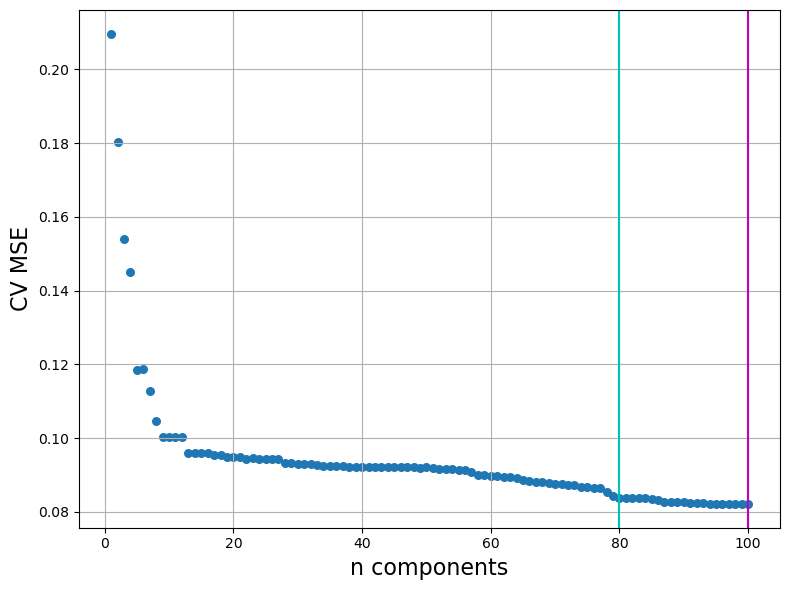

In [ ]:
param_grid = {'pca__n_components': np.linspace(1, 100, 100).astype('int')}

scaler = StandardScaler()
pca = PCA(random_state=88)
lr = LinearRegression()

pipe = Pipeline(steps=[('scaler', scaler), ('pca', pca), ('lr', lr)])

pcr_cv = GridSearchCV(pipe,
                      param_grid,
                      scoring='neg_mean_squared_error',
                      cv=10)
pcr_cv.fit(X_train_full, y_train)

n_components = pcr_cv.cv_results_['param_pca__n_components'].data
MSE_scores = pcr_cv.cv_results_['mean_test_score']*(-1)
x_min, x_1se = one_standard_error_rule(model='pcr',
                                       results=pcr_cv.cv_results_,
                                       param_grid=n_components,
                                       n_splits=10,
                                       neg_mean_squared_error=True)

plt.figure(figsize=(8, 6))
plt.xlabel('n components', fontsize=16)
plt.ylabel('CV MSE', fontsize=16)
plt.scatter(n_components, MSE_scores, s=30)
plt.grid(True, which='both')
plt.axvline(x=x_min, color='m')
plt.axvline(x=x_1se, color='c')
plt.tight_layout()
plt.show()

In [ ]:
lr_preds = pcr_cv.predict(X_test_full)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)
print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R^2:", lr_r2)

model_results.append({
    "Model": "Linear Regression (PCA)",
    "Best CV": np.nan,
    "Test RMSE": lr_rmse,
    "Test R^2": lr_r2
})

Linear Regression RMSE: 0.27991925691092867
Linear Regression R^2: 0.671503134244959


# CART (Baseline) + Tree Plot

In [ ]:
cart = DecisionTreeRegressor(max_depth=3, min_samples_leaf=50, random_state=88)
cart.fit(X_train_full, y_train)
cart_preds = cart.predict(X_test_full)
cart_rmse = np.sqrt(mean_squared_error(y_test, cart_preds))
cart_r2   = r2_score(y_test, cart_preds)
print("CART (Baseline) RMSE:", cart_rmse)
print("CART (Baseline) R^2:", cart_r2)

model_results.append({
    "Model": "CART (Baseline)",
    "Best CV": np.nan,
    "Test RMSE": cart_rmse,
    "Test R^2": cart_r2
})

CART (Baseline) RMSE: 0.3330037778099519
CART (Baseline) R^2: 0.5350952344401545


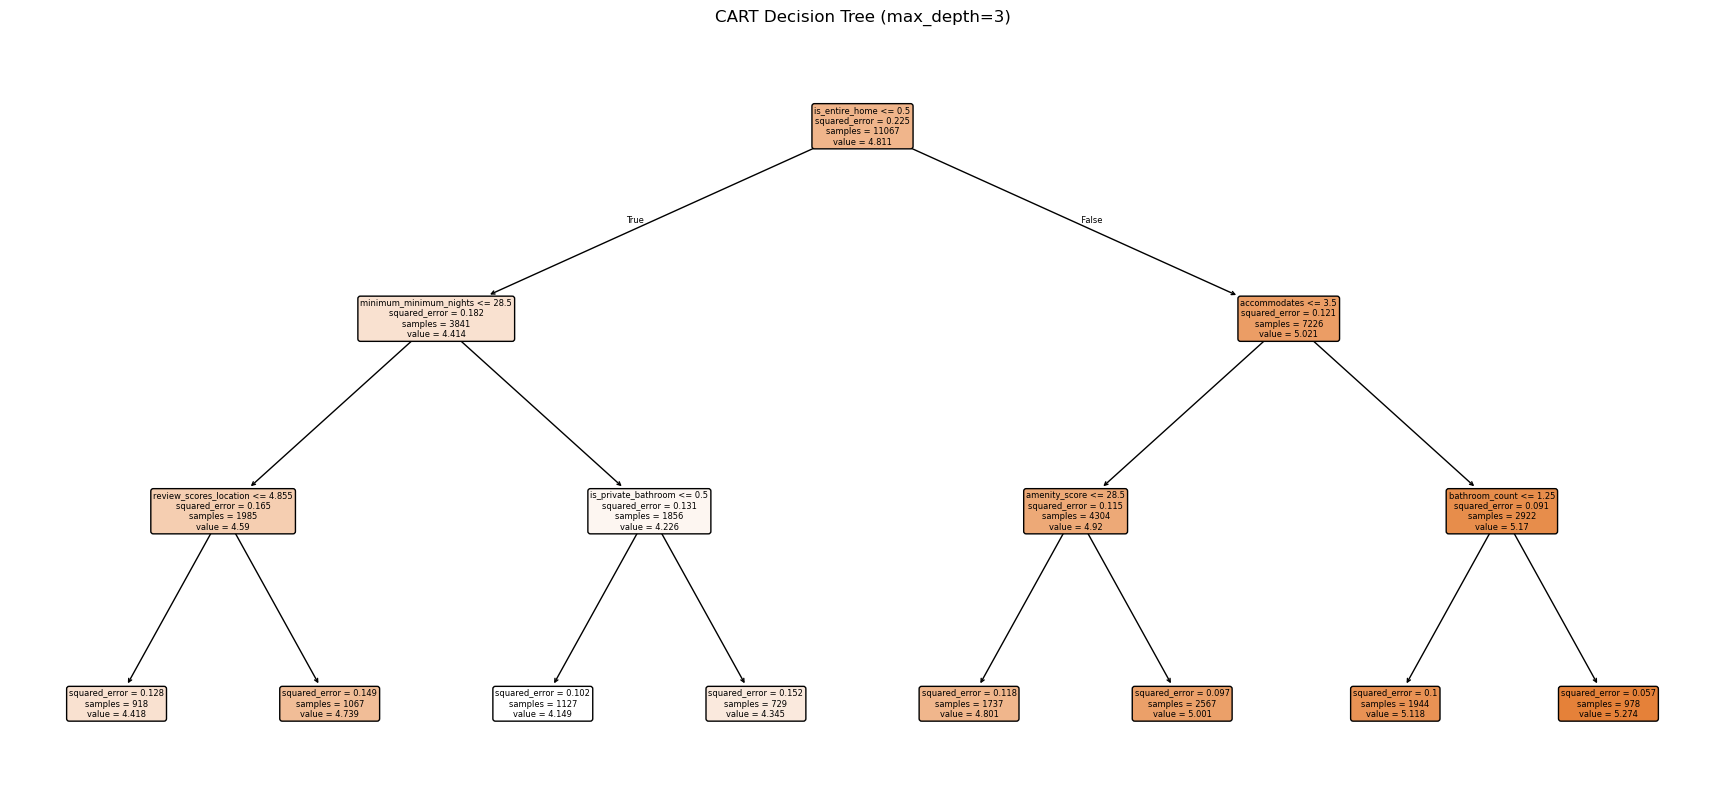

In [ ]:
# ---- Plot the tree ----
plt.figure(figsize=(22, 10))
tree.plot_tree(
    cart,
    feature_names=X_train_full.columns,
    filled=True,
    rounded=True,
    fontsize=6
)
plt.title("CART Decision Tree (max_depth=3)")
plt.show()

# MODEL 2: Random Forest with CV

In [ ]:
cv = KFold(n_splits=5,random_state=88,shuffle=True)

rf = RandomForestRegressor(random_state=88)

param = {
    'max_features': [10, 20 , 30],
    'n_estimators':[80, 160, 200],
    'max_depth':[10, 20, 50]
}
rf_cv = GridSearchCV(rf, param_grid=param, scoring='r2', cv=cv)
rf_cv.fit(X_train_full, y_train)
print("Best Param:", rf_cv.best_params_)
print("Best Estimator:", rf_cv.best_estimator_)

Best Param: {'max_depth': 50, 'max_features': 30, 'n_estimators': 200}
Best Estimator: RandomForestRegressor(max_depth=50, max_features=30, n_estimators=200,
                      random_state=88)


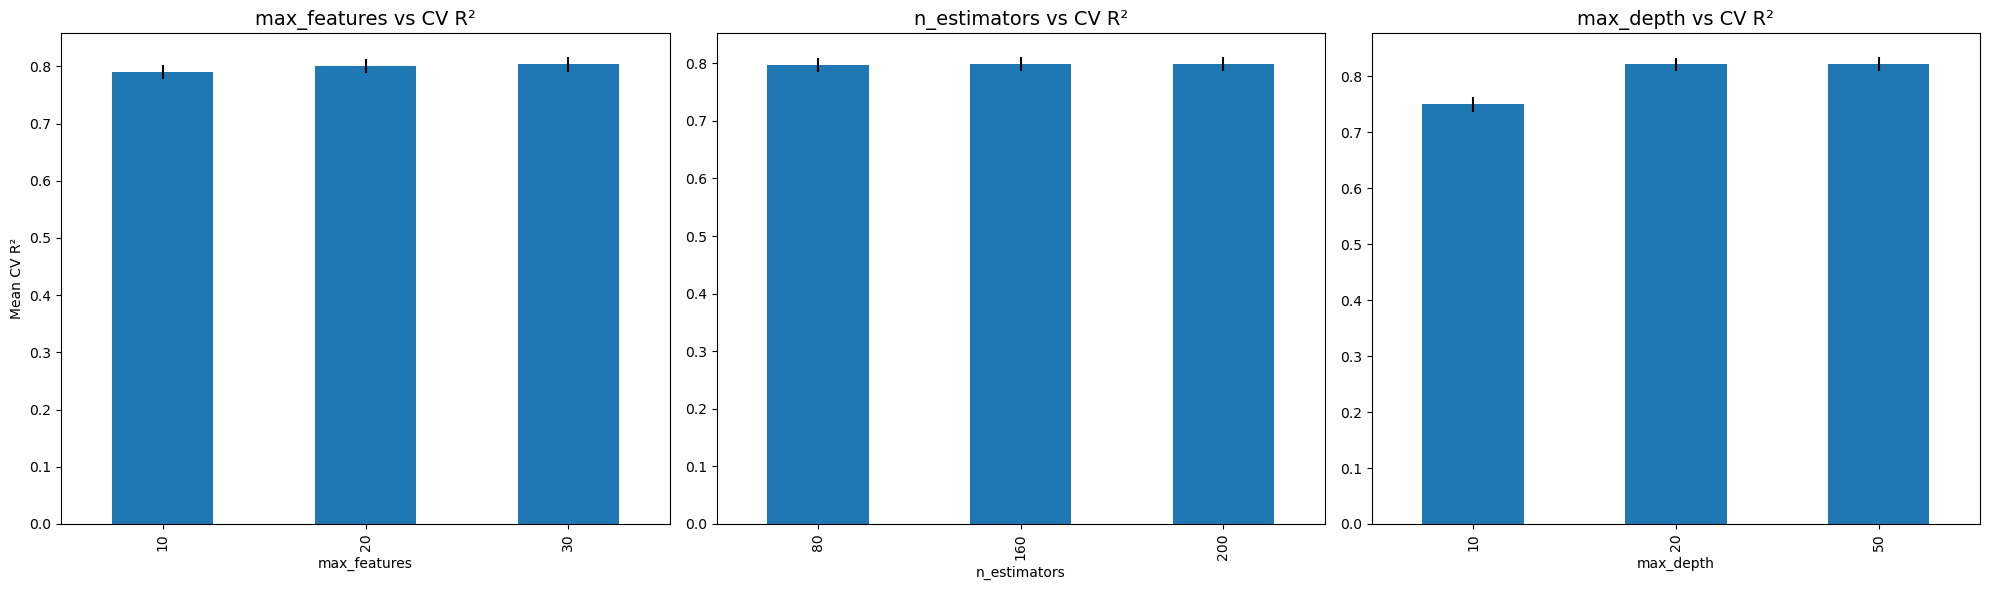

In [ ]:

results_df = pd.DataFrame(rf_cv.cv_results_)
results_df['mean_score'] = rf_cv.cv_results_['mean_test_score']
results_df['std_score'] = rf_cv.cv_results_['std_test_score']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

mf_pivot = results_df.pivot_table(values='mean_score', index='param_max_features',
                                 aggfunc='mean')
mf_pivot.plot(kind='bar', yerr=results_df.groupby('param_max_features')['std_score'].mean(),
              ax=axes[0], legend=False)
axes[0].set_title('max_features vs CV R²', fontsize=14)
axes[0].set_xlabel('max_features')
axes[0].set_ylabel('Mean CV R²')

ne_pivot = results_df.pivot_table(values='mean_score', index='param_n_estimators',
                                 aggfunc='mean')
ne_pivot.plot(kind='bar', yerr=results_df.groupby('param_n_estimators')['std_score'].mean(),
              ax=axes[1], legend=False)
axes[1].set_title('n_estimators vs CV R²', fontsize=14)
axes[1].set_xlabel('n_estimators')

md_pivot = results_df.pivot_table(values='mean_score', index='param_max_depth',
                                 aggfunc='mean')
md_pivot.plot(kind='bar', yerr=results_df.groupby('param_max_depth')['std_score'].mean(),
              ax=axes[2], legend=False)
axes[2].set_title('max_depth vs CV R²', fontsize=14)
axes[2].set_xlabel('max_depth')

plt.tight_layout()
plt.show()


In [ ]:
best_rf = rf_cv.best_estimator_
rf_test_pred = best_rf.predict(X_test_full)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))
rf_test_r2   = r2_score(y_test, rf_test_pred)

print("Random Forest Test RMSE:", rf_test_rmse)
print("Random Forest Test R^2:", rf_test_r2)

model_results.append({
    "Model": "Random Forest (tuned)",
    "Best CV": rf_cv.best_score_,
    "Test RMSE": rf_test_rmse,
    "Test R^2": rf_test_r2
})

Random Forest Test RMSE: 0.18435226555413706
Random Forest Test R^2: 0.8575171362591599


# MODEL 3: Gradient Boosting with CV

In [ ]:
gbr = GradientBoostingRegressor(random_state=88)

param_gbr = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 6, 10]
}

gbr_cv = GridSearchCV(estimator=gbr, param_grid=param_gbr, scoring="r2", cv=cv)

gbr_cv.fit(X_train_full, y_train)

print("Best GBR Params:", gbr_cv.best_params_)
print("Best GBR Estimator:", gbr_cv.best_estimator_)

Best GBR Params: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200}
Best GBR Estimator: GradientBoostingRegressor(max_depth=10, n_estimators=200, random_state=88)


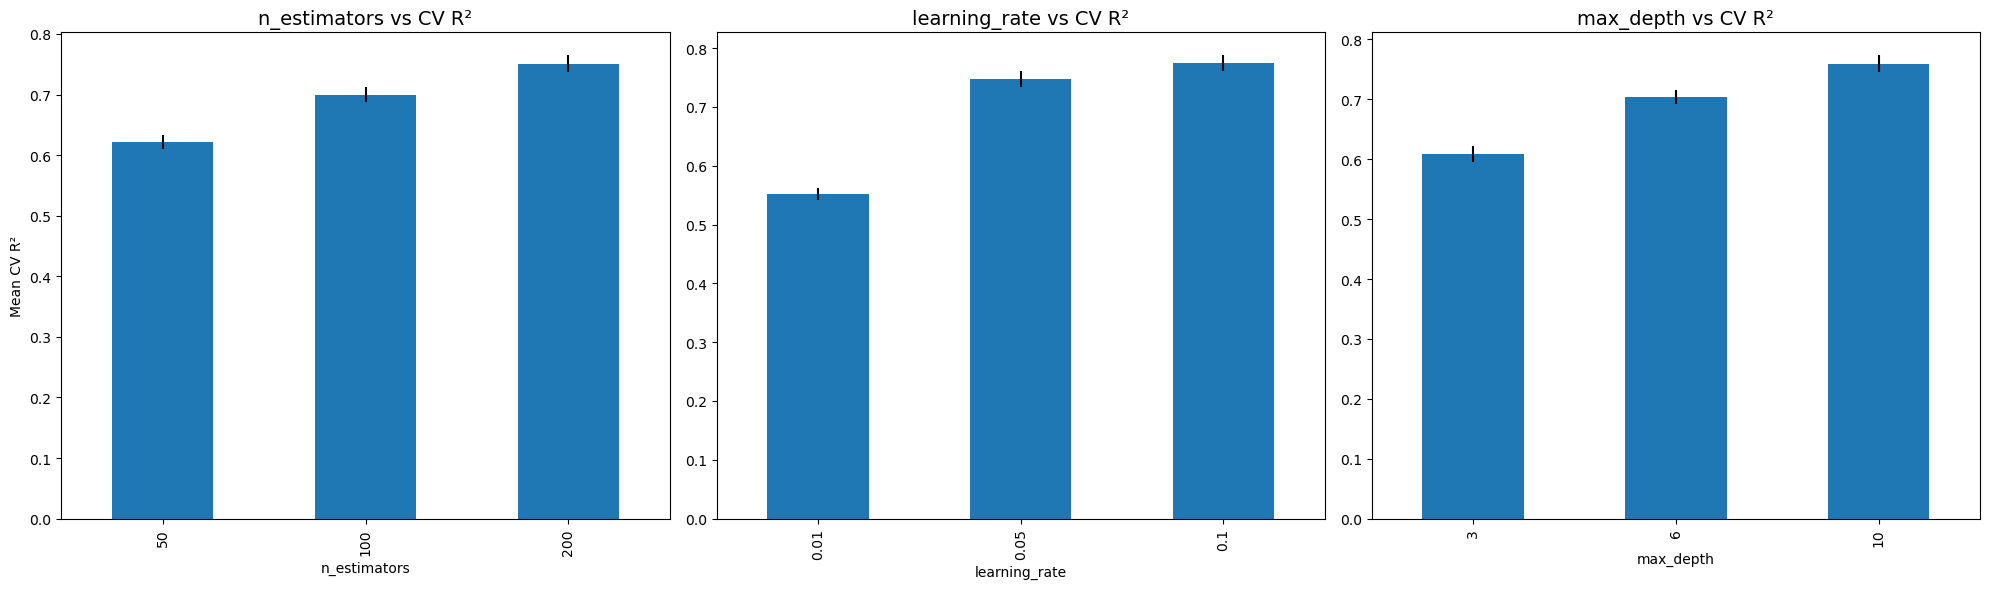

In [ ]:
results_df = pd.DataFrame(gbr_cv.cv_results_)
results_df['mean_score'] = gbr_cv.cv_results_['mean_test_score']
results_df['std_score'] = gbr_cv.cv_results_['std_test_score']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

mf_pivot = results_df.pivot_table(values='mean_score', index='param_n_estimators',
                                 aggfunc='mean')
mf_pivot.plot(kind='bar', yerr=results_df.groupby('param_n_estimators')['std_score'].mean(),
              ax=axes[0], legend=False)
axes[0].set_title('n_estimators vs CV R²', fontsize=14)
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('Mean CV R²')

ne_pivot = results_df.pivot_table(values='mean_score', index='param_learning_rate',
                                 aggfunc='mean')
ne_pivot.plot(kind='bar', yerr=results_df.groupby('param_learning_rate')['std_score'].mean(),
              ax=axes[1], legend=False)
axes[1].set_title('learning_rate vs CV R²', fontsize=14)
axes[1].set_xlabel('learning_rate')

md_pivot = results_df.pivot_table(values='mean_score', index='param_max_depth',
                                 aggfunc='mean')
md_pivot.plot(kind='bar', yerr=results_df.groupby('param_max_depth')['std_score'].mean(),
              ax=axes[2], legend=False)
axes[2].set_title('max_depth vs CV R²', fontsize=14)
axes[2].set_xlabel('max_depth')

plt.tight_layout()
plt.show()


In [ ]:
best_gbr = gbr_cv.best_estimator_
best_gbr.fit(X_train_full, y_train)
gbr_test_pred = best_gbr.predict(X_test_full)
gbr_test_rmse = np.sqrt(mean_squared_error(y_test, gbr_test_pred))
gbr_test_r2   = r2_score(y_test, gbr_test_pred)

print("\n===== Gradient Boosting Final Model Evaluation =====")
print("Test RMSE:", gbr_test_rmse)
print("Test R^2:", gbr_test_r2)

model_results.append({
    "Model": "Gradient Boosting (tuned)",
    "Best CV": gbr_cv.best_score_,
    "Test RMSE": gbr_test_rmse,
    "Test R^2": gbr_test_r2
})

# Comparison Table

In [ ]:
comparison_df = pd.DataFrame(model_results)
comparison_df = comparison_df.sort_values("Test RMSE")
comparison_df

# Boostrapping for 95% CI

In [ ]:
lr_r2_ci = []
rf_r2_ci = []
cart_r2_ci = []
gbr_r2_ci = []

lr_rmse_ci = []
rf_rmse_ci = []
cart_rmse_ci = []
gbr_rmse_ci = []

for sample_idx in range(500):
  boostrapped_x_test, boostrapped_y_test = resample(X_test_full, y_test, random_state=sample_idx)
  boostrapped_x_test = boostrapped_x_test[X_test_full.columns].reset_index(drop=True)

  # Linear Regression
  lr_preds = pcr_cv.predict(boostrapped_x_test)
  lr_r2 = r2_score(boostrapped_y_test, lr_preds)
  lr_rmse = np.sqrt(mean_squared_error(boostrapped_y_test, lr_preds))
  lr_r2_ci.append(lr_r2)
  lr_rmse_ci.append(lr_rmse)

  # CART
  cart_preds = cart.predict(boostrapped_x_test)
  cart_r2 = r2_score(boostrapped_y_test, cart_preds)
  cart_rmse = np.sqrt(mean_squared_error(boostrapped_y_test, cart_preds))
  cart_r2_ci.append(cart_r2)
  cart_rmse_ci.append(cart_rmse)

  # Random Forest
  rf_preds = best_rf.predict(boostrapped_x_test)
  rf_r2 = r2_score(boostrapped_y_test, rf_preds)
  rf_rmse = np.sqrt(mean_squared_error(boostrapped_y_test, rf_preds))
  rf_r2_ci.append(rf_r2)
  rf_rmse_ci.append(rf_rmse)

  # Gradient Boosting
  gbr_preds = best_gbr.predict(boostrapped_x_test)
  gbr_r2 = r2_score(boostrapped_y_test, gbr_preds)
  gbr_rmse = np.sqrt(mean_squared_error(boostrapped_y_test, gbr_preds))
  gbr_r2_ci.append(gbr_r2)
  gbr_rmse_ci.append(gbr_rmse)

In [ ]:
# table for lower 25% and higher 95% for all four models
ci_df = pd.DataFrame({
    "Model": ["Linear Regression", "CART", "Random Forest", "Gradient Boosting"],
    "Lower 25%": [np.quantile(lr_rmse_ci, 0.25), np.quantile(cart_rmse_ci, 0.25), np.quantile(rf_rmse_ci, 0.25), np.quantile(gbr_rmse_ci, 0.25)],
    "Higher 95%": [np.quantile(lr_rmse_ci, 0.95), np.quantile(cart_rmse_ci, 0.95), np.quantile(rf_rmse_ci, 0.95), np.quantile(gbr_rmse_ci, 0.95)]
})
ci_df.set_index("Model", inplace=True)
ci_df


,Lower 25%,Higher 95%
Model,,
Linear Regression,0.278169,0.284580
CART,0.330795,0.338832
Random Forest,0.181813,0.190691
Gradient Boosting,0.184302,0.196389


# Boostrap R2 Comparison Graph

(array([ 4.,  9.,  9., 24., 43., 45., 69., 63., 68., 61., 52., 26., 21.,
         3.,  3.]),
 array([0.82804896, 0.83115014, 0.83425132, 0.8373525 , 0.84045369,
        0.84355487, 0.84665605, 0.84975724, 0.85285842, 0.8559596 ,
        0.85906079, 0.86216197, 0.86526315, 0.86836434, 0.87146552,
        0.8745667 ]),
 <BarContainer object of 15 artists>)

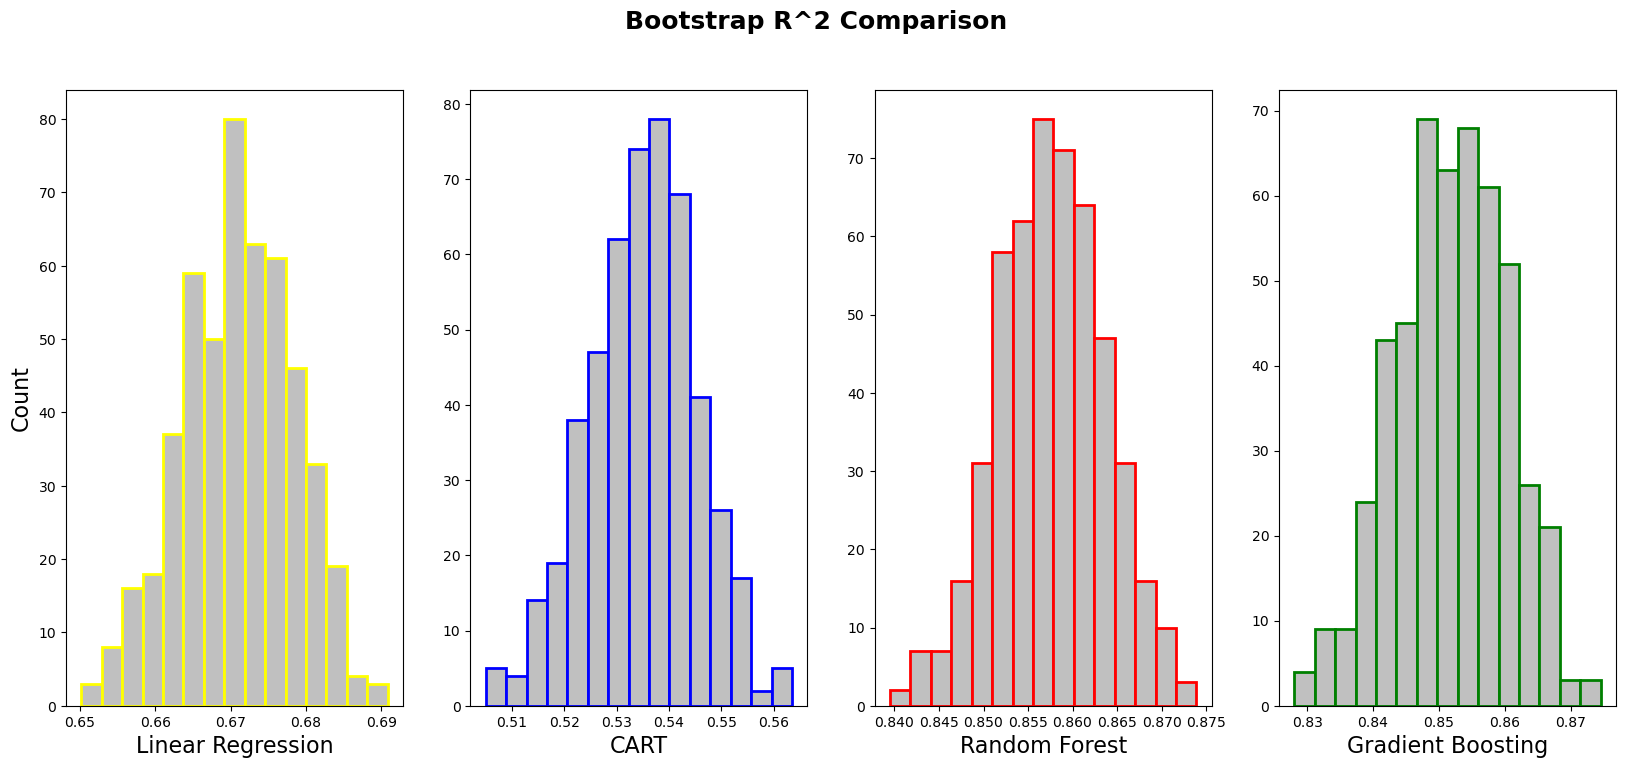

In [ ]:
# R2 graph comparison for CI
fig, axs = plt. subplots(ncols=4, figsize=(20,8))
fig.suptitle("Bootstrap R^2 Comparison", fontsize=18, fontweight='bold')
axs[0].set_xlabel('Linear Regression', fontsize=16)
axs[1].set_xlabel( 'CART', fontsize=16)
axs[2].set_xlabel( 'Random Forest', fontsize=16)
axs[3].set_xlabel( 'Gradient Boosting', fontsize=16)

axs[0].set_ylabel('Count', fontsize=16)
axs[0].hist(lr_r2_ci, bins=15, edgecolor='yellow', linewidth=2,color="silver")
axs[1].hist(cart_r2_ci, bins=15, edgecolor='blue', linewidth=2,color ="silver")
axs[2].hist(rf_r2_ci, bins=15, edgecolor='red', linewidth=2, color ="silver")
axs[3].hist(gbr_r2_ci, bins=15, edgecolor='green', linewidth=2, color ="silver")


# Boostrap RMSE Comparison Graph

(array([ 2., 14., 13., 29., 51., 61., 64., 67., 54., 64., 37., 21., 11.,
        11.,  1.]),
 array([0.17432184, 0.17620117, 0.1780805 , 0.17995982, 0.18183915,
        0.18371847, 0.1855978 , 0.18747713, 0.18935645, 0.19123578,
        0.1931151 , 0.19499443, 0.19687376, 0.19875308, 0.20063241,
        0.20251173]),
 <BarContainer object of 15 artists>)

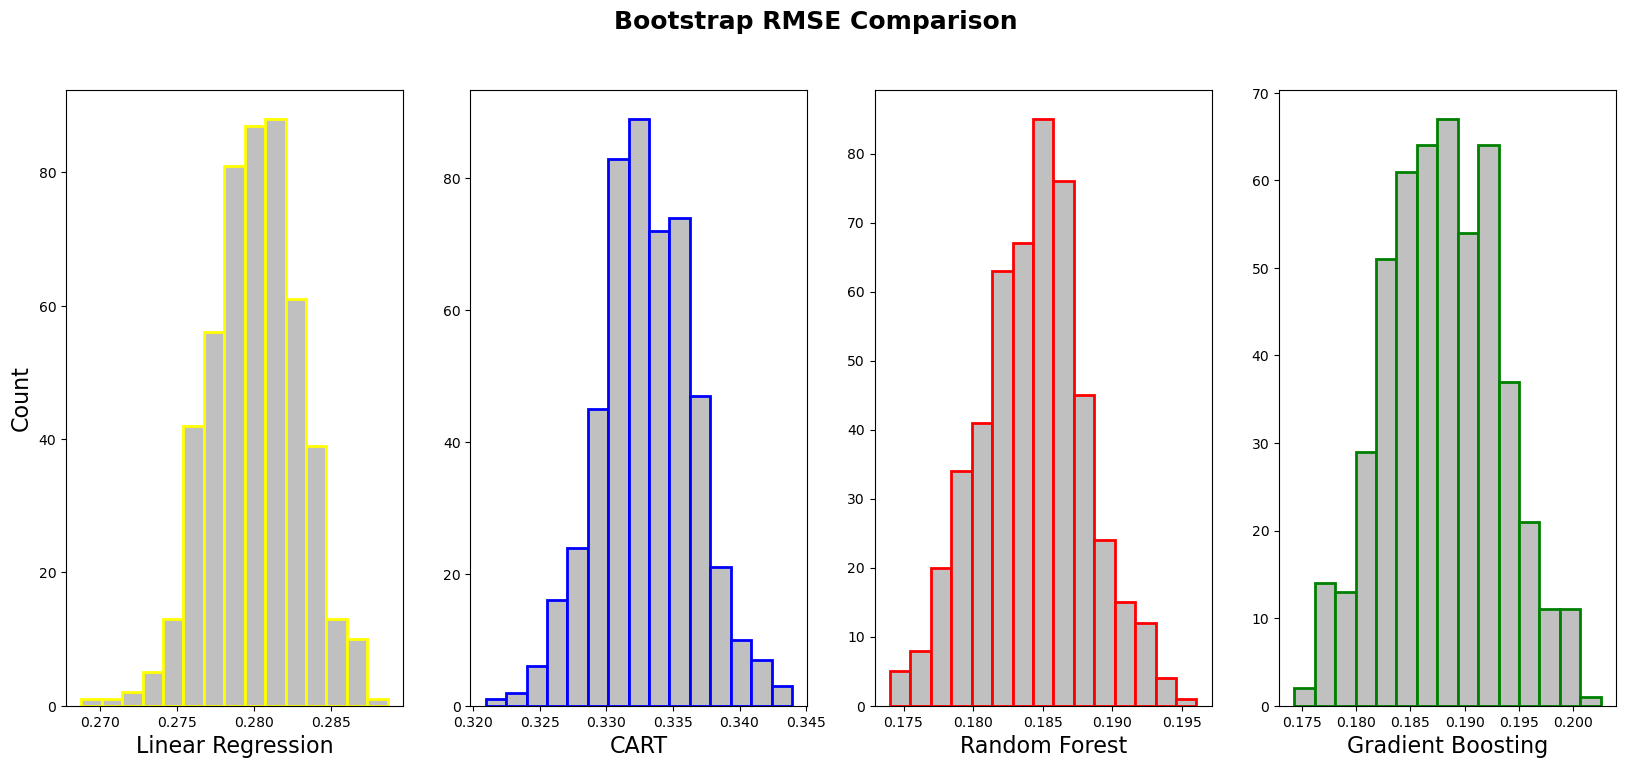

In [ ]:
# RSME graph comparison for CI
fig, axs = plt. subplots(ncols=4, figsize=(20,8))
fig.suptitle("Bootstrap RMSE Comparison", fontsize=18, fontweight='bold')
axs[0].set_xlabel('Linear Regression', fontsize=16)
axs[1].set_xlabel( 'CART', fontsize=16)
axs[2].set_xlabel( 'Random Forest', fontsize=16)
axs[3].set_xlabel( 'Gradient Boosting', fontsize=16)

axs[0].set_ylabel('Count', fontsize=16)
axs[0].hist(lr_rmse_ci, bins=15, edgecolor='yellow', linewidth=2,color="silver")
axs[1].hist(cart_rmse_ci, bins=15, edgecolor='blue', linewidth=2,color ="silver")
axs[2].hist(rf_rmse_ci, bins=15, edgecolor='red', linewidth=2, color ="silver")
axs[3].hist(gbr_rmse_ci, bins=15, edgecolor='green', linewidth=2, color ="silver")


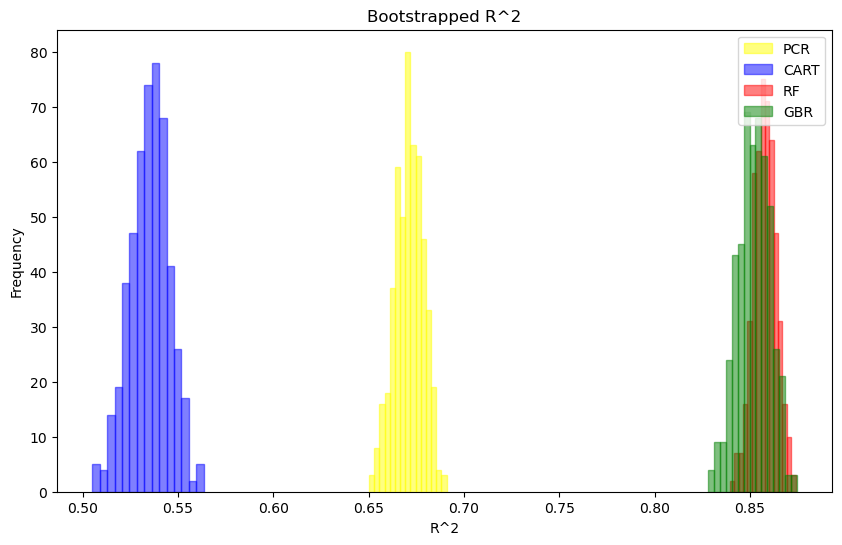

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(lr_r2_ci, bins=15, alpha=0.5, label='PCR', color='yellow', edgecolor='yellow')
plt.hist(cart_r2_ci, bins=15, alpha=0.5, label='CART', color='blue', edgecolor='blue')
plt.hist(rf_r2_ci, bins=15, alpha=0.5, label='RF', color='red', edgecolor='red')
plt.hist(gbr_r2_ci, bins=15, alpha=0.5, label='GBR', color='green', edgecolor='green')

plt.title('Bootstrapped R^2')
plt.xlabel('R^2')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.show()

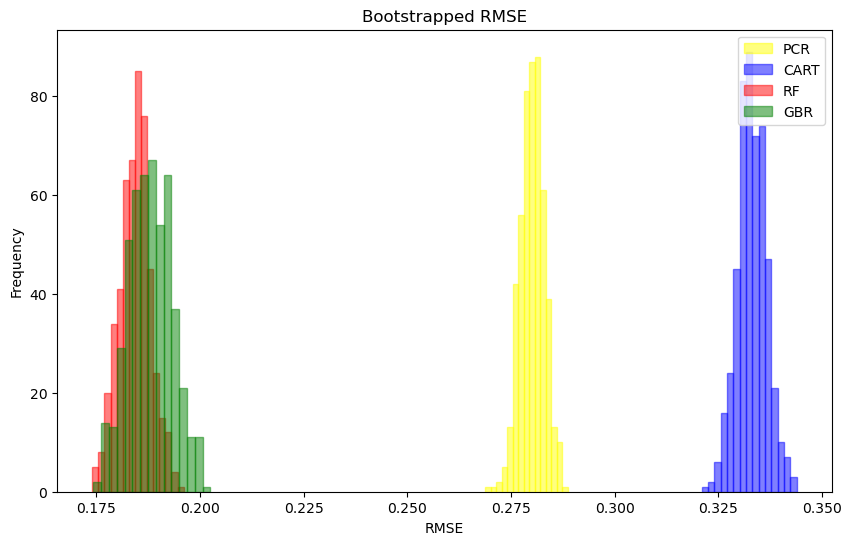

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(lr_rmse_ci, bins=15, alpha=0.5, label='PCR', color='yellow', edgecolor='yellow')
plt.hist(cart_rmse_ci, bins=15, alpha=0.5, label='CART', color='blue', edgecolor='blue')
plt.hist(rf_rmse_ci, bins=15, alpha=0.5, label='RF', color='red', edgecolor='red')
plt.hist(gbr_rmse_ci, bins=15, alpha=0.5, label='GBR', color='green', edgecolor='green')

plt.title('Bootstrapped RMSE')
plt.xlabel('RMSE')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.show()

In [ ]:
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc
!pip install pypandoc

from google.colab import drive
drive.mount('/content/drive')

file_path = "./drive/My Drive/Li (2).ipynb"
!cp "/content/drive/My Drive/Li (2).ipynb" ./
!jupyter nbconvert --to PDF "Li (2).ipynb"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries
  texlive-fonts-recommended texlive-latex-base texlive-latex-recommended
  texlive-pictures texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto f